In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px  # interactive figures
import plotly.graph_objects as go
import seaborn as sns


In [2]:
import pandas as pd

df = pd.read_csv("../data_raw/date_24_art1_loreal.csv")

df.head()

,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_CU_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC
0,01-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0
1,02-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0
2,03-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,770.0,574.75,0.0,0.0,72.25,278,267,0
3,04-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,770.0,574.75,0.0,0.0,72.29,267,376,0
4,05-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,700.0,522.50,0.0,0.0,65.72,376,366,0


standard deviation is a way to measure how "spread out" or "different" the values in a group are from the average.

If the standard deviation is small, it means most values are close to the average (not much variation).
If the standard deviation is large, it means the values are spread out and vary a lot from the average.

Conversie coloana data din object in datetime

In [3]:
df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")

C:\Users\Mara\AppData\Local\Temp\ipykernel_38996\2340964975.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATA                 734 non-null    datetime64[ns]
 1   ID_ARTICOL           734 non-null    int64         
 2   ARTICOL              734 non-null    object        
 3   CANTITATE            734 non-null    int64         
 4   VAL_IESIRE_FARA_TVA  734 non-null    float64       
 5   VAL_IESIRE_CU_TVA    734 non-null    float64       
 6   VAL_INTRARE_CU_TVA   734 non-null    float64       
 7   TOTAL_DISCOUNT       734 non-null    float64       
 8   RATA_DISCOUNT        703 non-null    float64       
 9   ADAOS                734 non-null    float64       
 10  STOC_INITIAL         734 non-null    int64         
 11  STOC_FINAL           734 non-null    int64         
 12  RUPTURA_STOC         734 non-null    int64         
dtypes: datetime64[ns](1), float64(6), i

In [5]:
# Sortare logică pentru time series
df = df.sort_values(by=["DATA"]).reset_index(drop=True)

In [6]:
# reguli de calitate
checks = {}

# 1) vânzare > 0 dar valoare = 0 (suspect)
checks["qty_pos_val_zero"] = df[(df["CANTITATE"] > 0) & (df["VAL_IESIRE_CU_TVA"] == 0)]

# 2) valoare > 0 dar cantitate = 0 (suspect)
checks["val_pos_qty_zero"] = df[(df["VAL_IESIRE_CU_TVA"] > 0) & (df["CANTITATE"] == 0)]

# 3) stoc final negativ (dacă există în dataset)
if "STOC_FINAL" in df.columns:
    checks["stoc_final_negativ"] = df[df["STOC_FINAL"] < 0]

# 4) discount > 0 dar rata_discount = 0 (suspect)
if "TOTAL_DISCOUNT" in df.columns and "RATA_DISCOUNT" in df.columns:
    checks["disc_pos_rata_zero"] = df[(df["TOTAL_DISCOUNT"] > 0) & (df["RATA_DISCOUNT"] == 0)]

# 5) 
checks["stockout_start"] = df[(df["STOC_INITIAL"] == 0) & (df["CANTITATE"] == 0)]
checks["no_sales_but_in_stock"] = df[(df["STOC_INITIAL"] > 0) & (df["CANTITATE"] == 0)]

{k: v.shape[0] for k, v in checks.items()}

{'qty_pos_val_zero': 0,
 'val_pos_qty_zero': 0,
 'stoc_final_negativ': 0,
 'disc_pos_rata_zero': 0,
 'stockout_start': 0,
 'no_sales_but_in_stock': 16}

In [7]:
cols = ["CANTITATE", "STOC_INITIAL", "STOC_FINAL", "VAL_IESIRE_FARA_TVA"]

(df[cols] < 0).sum()


CANTITATE              0
STOC_INITIAL           0
STOC_FINAL             0
VAL_IESIRE_FARA_TVA    0
dtype: int64

In [8]:
# df = df.set_index('DATA') 

In [9]:
# df

Pentru evitarea redundanței informaționale, variabilele puternic corelate vor fi filtrate.  ( gen val iesire cu fara tva, total discount - rata discount )

In [10]:
df_feat = df.drop(columns=[ "STOC_FINAL", "RUPTURA_STOC", "VAL_IESIRE_CU_TVA", "RATA_DISCOUNT"])

df_feat


,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_INTRARE_CU_TVA,TOTAL_DISCOUNT,ADAOS,STOC_INITIAL
0,2024-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278
1,2024-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278
2,2024-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,574.75,0.0,72.25,278
3,2024-01-04,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,574.75,0.0,72.29,267
4,2024-01-05,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,522.50,0.0,65.72,376
...,...,...,...,...,...,...,...,...,...
729,2025-12-30,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,12,719.02,627.00,0.0,92.02,1441
730,2025-12-31,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,419.44,365.75,0.0,53.69,1429
731,2026-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422
732,2026-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422


In [11]:

df_feat["DOW"] = df_feat["DATA"].dt.dayofweek          # 0..6
df_feat["ESTE_WEEKEND"] = (df_feat["DOW"] >= 5).astype(int)

# dacă ai deja LUNA ca yyyy-mm, păstreaz-o ca perioadă (opțional)
# df_feat["YYYY_MM"] = df_feat["DATA"].dt.to_period("M").astype(str)

# opțional: zi din lună (uneori surprinde patternuri de început/sfârșit)
df_feat["ZI_DIN_LUNA"] = df_feat["DATA"].dt.day

df_feat


,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_INTRARE_CU_TVA,TOTAL_DISCOUNT,ADAOS,STOC_INITIAL,DOW,ESTE_WEEKEND,ZI_DIN_LUNA
0,2024-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278,0,0,1
1,2024-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,278,1,0,2
2,2024-01-03,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,574.75,0.0,72.25,278,2,0,3
3,2024-01-04,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,574.75,0.0,72.29,267,3,0,4
4,2024-01-05,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,522.50,0.0,65.72,376,4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
729,2025-12-30,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,12,719.02,627.00,0.0,92.02,1441,1,0,30
730,2025-12-31,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,7,419.44,365.75,0.0,53.69,1429,2,0,31
731,2026-01-01,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422,3,0,1
732,2026-01-02,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.00,0.0,0.00,1422,4,0,2


In [12]:
fig = px.line(df, x='DATA', y='CANTITATE', title='Time Series with Range Slider and Selectors')

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            # dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

fig.update_layout(width=1100, height=500)
fig.show()

## ARIMA

In [13]:
# df_art = df.set_index("DATA")["CANTITATE"].asfreq("D")
# ARIMA works with series, not dataframes
df_art = (
    df
    .set_index("DATA")["CANTITATE"]
    .astype(float)
    .sort_index()
)


In [14]:
df_art

DATA
2024-01-01     0.0
2024-01-02     0.0
2024-01-03    11.0
2024-01-04    11.0
2024-01-05    10.0
              ... 
2025-12-30    12.0
2025-12-31     7.0
2026-01-01     0.0
2026-01-02     0.0
2026-01-03    13.0
Name: CANTITATE, Length: 734, dtype: float64

In [15]:
df_art.map(type).value_counts().head(10)


CANTITATE
<class 'float'>    734
Name: count, dtype: int64

In [16]:
type(df_art)
df_art.name
df_art.index.name
df_art.dtype
df_art.head()


DATA
2024-01-01     0.0
2024-01-02     0.0
2024-01-03    11.0
2024-01-04    11.0
2024-01-05    10.0
Name: CANTITATE, dtype: float64

In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning:

In the future `np.object` will be defined as the corresponding NumPy scalar.



In [18]:
# pip install tensorflow

In [19]:
forecast_horizon_daily = 30
n = len(df_art)
if forecast_horizon_daily >= n:
    raise ValueError("forecast_horizon_daily must be smaller than the series length")

split_idx = n - forecast_horizon_daily

split_idx


587

In [20]:
train = df_art.iloc[:split_idx]
test  = df_art.iloc[split_idx:]

In [21]:
# train.DATA.max(), test.DATA.min()

In [22]:
# import libraries
from statsmodels.tsa.stattools import adfuller

# ADF test
result = adfuller(train.dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# if p-value > 0.05, the series is non-stationary and needs differencing
if result[1] > 0.05:
    print("needs differencing")
else:
    print("time series is stationary")

ADF Statistic: -3.7874346810000405
p-value: 0.003038522956429229
time series is stationary


In [23]:
from pmdarima import auto_arima

model_auto = auto_arima(
    train,
    seasonal=False,
    d=None,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

selected_order = model_auto.order
selected_order


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=3750.792, Time=0.22 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=4858.772, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=3836.232, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=4417.711, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=3745.149, Time=0.10 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=4187.805, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=3750.083, Time=0.06 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=3735.923, Time=0.15 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=4067.301, Time=0.10 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=3737.408, Time=0.22 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=3736.713, Time=0.12 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=4017.534, Time=0.15 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=3733.086, Time=0.28 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=3729.236, Time=0.56 sec
 ARIMA(3,0,3)(0,0,0)[0]          

(5, 0, 4)

In [24]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train, order=selected_order)
arima_fit = arima.fit()


C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Mara\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [25]:
pred_arima = arima_fit.forecast(steps=forecast_horizon_daily)


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test, pred_arima)

mse = mean_squared_error(test, pred_arima)
rmse = np.sqrt(mse)

# mape = np.mean(np.abs((y_true - pred) / np.maximum(y_true, 1))) * 100

r2 = r2_score(test, pred_arima)


mae = float(mae)
rmse = float(rmse)


mae, mse, rmse,  r2

## fara r2



(7.0267202407421125,
 124.53181824938295,
 11.159382520972338,
 0.0009644838365682196)

In [27]:
import numpy as np

r = np.corrcoef(test, pred_arima)[0, 1]
float(r)
# arata daca modelul urmareste trandul, nu cat de exact prezice

0.0426334787607541

In [28]:
import pandas as pd
import plotly.express as px

df_plot_arima = pd.DataFrame({
    "DATA": test.index,
    "Actual": test.values,
    "Predicted": pred_arima
})

df_long_arima = df_plot_arima.melt(
    id_vars="DATA",
    value_vars=["Actual", "Predicted"],
    var_name="Serie",
    value_name="Cantitate"
)

fig = px.line(
    df_long_arima,
    x="DATA",
    y="Cantitate",
    color="Serie",
    title="ARIMA – Actual vs Predicted"
)

fig.update_layout(
    xaxis_title="Data",
    yaxis_title="Cantitate vândută",
    hovermode="x unified",
    legend_title_text=""
)

fig.update_xaxes(rangeslider_visible=True)

fig.show()



## ACF / PACF TEST

<Figure size 1000x400 with 0 Axes>

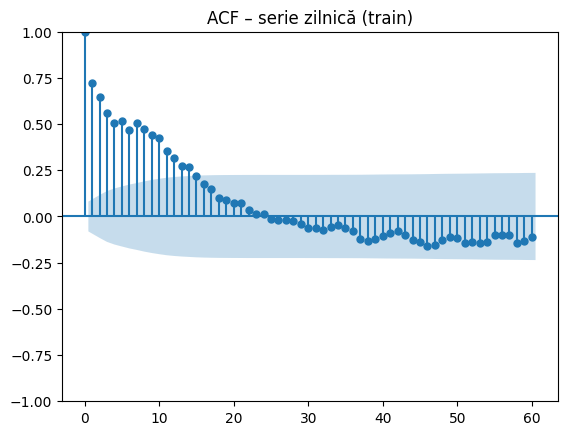

<Figure size 1000x400 with 0 Axes>

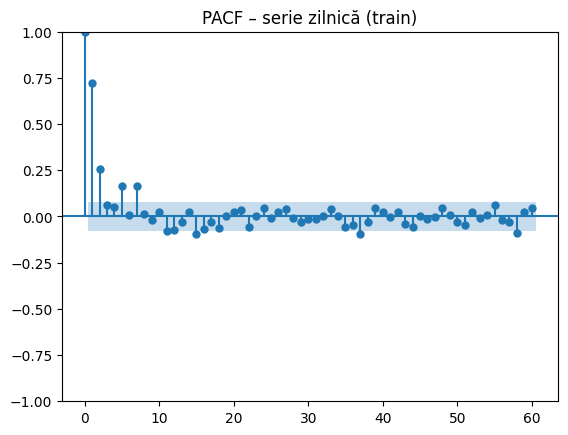

In [29]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(10,4))
plot_acf(train, lags=60)
plt.title("ACF – serie zilnică (train)")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(train, lags=60, method="ywm")
plt.title("PACF – serie zilnică (train)")
plt.show()


## STL

In [30]:
from statsmodels.tsa.seasonal import STL

stl = STL(df, period=7, robust=True)
res = stl.fit()

res.plot()
plt.show()


TypeError: float() argument must be a string or a real number, not 'Timestamp'

## SARIMA

In [ ]:
# pip install pmdarima  (dacă nu e instalat)
from pmdarima import auto_arima

sarima_weekly = auto_arima(
    train,
    seasonal=True,
    m=7,                 # sezonalitate săptămânală
    d=None, D=None,      # lasă auto_arima să aleagă diferențierea
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True
)

print("Model:", sarima_weekly.order, sarima_weekly.seasonal_order)


In [ ]:
pred_weekly = pd.Series(
    sarima_weekly.predict(n_periods=len(test)),
    index=test.index
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(test, pred_weekly)
rmse = np.sqrt(mean_squared_error(test, pred_weekly))
r2 = r2_score(test, pred_weekly)

print("SARIMA weekly | MAE:", mae, "RMSE:", rmse, "R2:", r2)


## SARIMA ( DF MONTHLY )

In [ ]:
df_monthly = df_art.resample("MS").sum()  # ?nceput de lun?; sum? cantit??i pe lun?

forecast_horizon_monthly = 3
if forecast_horizon_monthly >= len(df_monthly):
    raise ValueError("forecast_horizon_monthly must be smaller than the monthly series length")

split_idx_m = len(df_monthly) - forecast_horizon_monthly
train_m = df_monthly.iloc[:split_idx_m]
test_m  = df_monthly.iloc[split_idx_m:]


In [ ]:
len(train_m) // 2

In [ ]:
plt.figure(figsize=(10,4))
plot_acf(train_m, lags=10)
plt.title("ACF – serie lunară (train)")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(train_m, lags=10, method="ywm")
plt.title("PACF – serie lunară (train)")
plt.show()


# lags - pe ce timeline modelam : 10 luni in acest caz

In [ ]:
sarima_monthly = auto_arima(
    train_m,
    seasonal=True,
    m=12,              # sezonalitate anuală pe lună
    d=None, D=None,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True
)

print("Model:", sarima_monthly.order, sarima_monthly.seasonal_order)

pred_m = pd.Series(
    sarima_monthly.predict(n_periods=len(test_m)),
    index=test_m.index
)

mae_m = mean_absolute_error(test_m, pred_m)
rmse_m = np.sqrt(mean_squared_error(test_m, pred_m))
r2_m = r2_score(test_m, pred_m)

print("SARIMA monthly | MAE:", mae_m, "RMSE:", rmse_m, "R2:", r2_m)


In [ ]:
import plotly.express as px

df_plot = pd.DataFrame({
    "DATA": test.index,
    "Actual": test.values,
    "Pred_SARIMA_weekly": pred_weekly.values
})

df_long = df_plot.melt("DATA", var_name="Serie", value_name="Cantitate")

fig = px.line(df_long, x="DATA", y="Cantitate", color="Serie",
              title="SARIMA (m=7) – Actual vs Predicted (test)")
fig.update_layout(hovermode="x unified", xaxis_title="Data", yaxis_title="Cantitate")
fig.update_xaxes(rangeslider_visible=True)
fig.show()


In [ ]:
df_plot_m = pd.DataFrame({
    "DATA": test_m.index,
    "Actual": test_m.values,
    "Pred_SARIMA_monthly": pred_m.values
})

df_long_m = df_plot_m.melt("DATA", var_name="Serie", value_name="Cantitate")

fig = px.line(df_long_m, x="DATA", y="Cantitate", color="Serie",
              title="SARIMA (m=12) – Actual vs Predicted (test, lunar)")
fig.update_layout(hovermode="x unified", xaxis_title="Luna", yaxis_title="Cantitate (sumă lunară)")
fig.update_xaxes(rangeslider_visible=True)
fig.show()


In [ ]:
import pandas as pd
import numpy as np

df_smx = df.copy()
df_smx["DATA"] = pd.to_datetime(df_smx["DATA"])
df_smx = df_smx.sort_values("DATA")


# selectăm coloanele
cols = ["DATA", "CANTITATE", "RATA_DISCOUNT", "STOC_INITIAL"]
df_smx = df_smx[cols]

# agregare zilnică
daily = df_smx.groupby("DATA", as_index=False).agg({
    "CANTITATE": "sum",
    "RATA_DISCOUNT": "mean",
    "STOC_INITIAL": "mean"
})

# completare zile lipsă
daily = daily.set_index("DATA").asfreq("D").fillna(0).reset_index()

daily.head()


In [ ]:
split_idx = len(daily) - forecast_horizon_daily

train = daily.iloc[:split_idx].copy()
test  = daily.iloc[split_idx:].copy()

y_train = train["CANTITATE"]
y_test  = test["CANTITATE"]

X_train = train[["RATA_DISCOUNT", "STOC_INITIAL"]]
X_test  = test[["RATA_DISCOUNT", "STOC_INITIAL"]]


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 0),          # ARIMA(1,0,0)
    seasonal_order=(0, 0, 0, 0),  # fără sezonalitate
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
print(model_fit.summary())


In [ ]:
pred_sarimax = model_fit.forecast(
    steps=len(test),
    exog=X_test
)

pred_sarimax = np.maximum(pred_sarimax, 0)  # retail safety


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, pred_sarimax)
rmse = np.sqrt(mean_squared_error(y_test, pred_sarimax))
r2 = r2_score(y_test, pred_sarimax)

mae, rmse, r2


In [ ]:
import plotly.express as px

df_plot = pd.DataFrame({
    "DATA": test["DATA"],
    "Actual": y_test.values,
    "Pred_SARIMAX": pred_sarimax.values
})

df_long = df_plot.melt("DATA", var_name="Serie", value_name="Cantitate")

fig = px.line(
    df_long,
    x="DATA",
    y="Cantitate",
    color="Serie",
    title="SARIMAX – Actual vs Predicted (test)"
)

fig.update_layout(
    hovermode="x unified",
    xaxis_title="Data",
    yaxis_title="Cantitate"
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()
